# 📊 Notebook 01 — EDA & Data Preparation
## Bagian 0: Eksplorasi Data Awal & Persiapan Dataset

**Dataset:** 8.099 ulasan CoreTax/M-Pajak dari Google Play Store

**Tujuan:**
1. Loading dan inspeksi data
2. Normalisasi ringan
3. Feature engineering sederhana
4. Visualisasi distribusi & tren

## Setup & Imports

In [1]:
import sys
import os

# Tambahkan root project ke path
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import module proyek
from src.preprocessing import load_raw_data, normalize_text_basic, add_engineered_features, prepare_dataset
from src.evaluator import plot_rating_distribution, plot_monthly_trend, plot_wordcloud

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_colwidth', 100)

## 0.1 — Loading & Eksplorasi Dasar

In [2]:
# Load raw data
df_raw = load_raw_data('../data/raw/coretax_reviews.csv')
print(f"\n📊 Dataset Shape: {df_raw.shape}")
print(f"\n📋 Kolom: {list(df_raw.columns)}")
print(f"\n📅 Rentang tanggal: {df_raw['date'].min()} — {df_raw['date'].max()}")


📊 Dataset Shape: (8102, 6)

📋 Kolom: ['user_name', 'rating', 'date', 'review_text', 'likes', 'app_version']

📅 Rentang tanggal: 2021-06-04 18:42:28 — 2026-05-04 09:07:50


In [3]:
# Distribusi rating
print("\n📊 Distribusi Rating:")
print(df_raw['rating'].value_counts().sort_index())


📊 Distribusi Rating:
rating
1    6134
2     330
3     203
4     154
5    1281
Name: count, dtype: int64


In [4]:
# Duplikat teks (untuk informasi, TIDAK dihapus)
n_dup = df_raw['review_text'].duplicated().sum()
print(f"\n📊 Review duplikat: {n_dup} ({n_dup/len(df_raw)*100:.1f}%)")
print("   ℹ️  Duplikat DIPERTAHANKAN untuk menjaga volume keluhan asli")


📊 Review duplikat: 763 (9.4%)
   ℹ️  Duplikat DIPERTAHANKAN untuk menjaga volume keluhan asli


In [5]:
# Missing values
print("\n📊 Missing Values:")
print(df_raw.isnull().sum())


📊 Missing Values:
user_name      0
rating         0
date           0
review_text    0
likes          0
app_version    0
dtype: int64


In [6]:
# Sample review per rating
for r in [1, 3, 5]:
    sample = df_raw[df_raw['rating'] == r]['review_text'].head(3)
    print(f"\n⭐ Rating {r} — Contoh:")
    for text in sample:
        print(f"   • {str(text)[:100]}")


⭐ Rating 1 — Contoh:
   • herman kenapa cuma verivikasi otp nomor telepon . musti pake pulsa? sekelas negara yang butuh pajak 
   • Harus diperbaiki lagi sih ini. Tolong dong, ngga mungkin se abai itu para pekerja dan pengembang apl
   • ini menurut beyond BNI. adalah aplikasi pishing. hati hati.

⭐ Rating 3 — Contoh:
   • seharusnya dengan app ini, proses pelaporan jadi lebih mudah. Sangat disayangkan, belum bisa diopera
   • gk pernah bisa masuk setelah log in, layar blank putih, dan saran untuk informasi pengikinian data d
   • kami setiap thn sllu aktik bayar pajak

⭐ Rating 5 — Contoh:
   • terbantu dengan pelayanan ini terimakasih 🙏
   • apk sampah ga bisa di gunakan
   • good


## 0.2 — Normalisasi Ringan & Feature Engineering

In [7]:
# Jalankan pipeline persiapan data lengkap
df = prepare_dataset(
    filepath='../data/raw/coretax_reviews.csv',
    output_path='../data/processed/reviews_prepared.csv'
)

📦 Bagian 0 — Data Processing (Persiapan Data)

🔄 Step 1: Loading data...
   ✅ Loaded 8102 baris
   📊 Distribusi rating:
      ⭐ 1: 6134 (75.7%)
      ⭐ 2: 330 (4.1%)
      ⭐ 3: 203 (2.5%)
      ⭐ 4: 154 (1.9%)
      ⭐ 5: 1281 (15.8%)

🔄 Step 2: Normalisasi ringan...
   ✅ Normalisasi teks dasar selesai

🔄 Step 3: Feature engineering...
   ✅ Fitur ditambahkan: word_count, char_count, year_month, is_duplicate
   📊 Duplikat teks: 938 baris (11.6%)

💾 Dataset tersimpan: ../data/processed/reviews_prepared.csv
   Total baris: 8102


In [8]:
# Preview hasil
print("\n📋 Preview Dataset Setelah Persiapan:")
print(df[['rating', 'review_text', 'word_count', 'char_count', 'year_month', 'is_duplicate']].head(5))


📋 Preview Dataset Setelah Persiapan:
   rating  \
0       1   
1       4   
2       1   
3       1   
4       1   

                                                                                           review_text  \
0  herman kenapa cuma verivikasi otp nomor telepon . musti pake pulsa? sekelas negara yang butuh pa...   
1                                                                            kenapa ya gk bisa swafoto   
2  Harus diperbaiki lagi sih ini. Tolong dong, ngga mungkin se abai itu para pekerja dan pengembang...   
3                                          ini menurut beyond BNI. adalah aplikasi pishing. hati hati.   
4  sebenarnya apk ini ada maafnya gak?apk pemerintah kenapa seperti ini buang buang uang tapi tidak...   

   word_count  char_count year_month  is_duplicate  
0          26         157    2026-05         False  
1           5          25    2026-05         False  
2          28         173    2026-05         False  
3           9          59    2026-

In [9]:
# Statistik panjang teks
print("\n📊 Statistik Panjang Teks:")
print(df['word_count'].describe())
print(f"\n   Review pendek (≤ 2 kata): {(df['word_count'] <= 2).sum()} "
      f"({(df['word_count'] <= 2).sum()/len(df)*100:.1f}%)")


📊 Statistik Panjang Teks:
count    8102.000000
mean       13.004443
std        13.218296
min         1.000000
25%         3.000000
50%         9.000000
75%        18.000000
max        92.000000
Name: word_count, dtype: float64

   Review pendek (≤ 2 kata): 1526 (18.8%)


## 0.3 — Visualisasi Distribusi & Tren

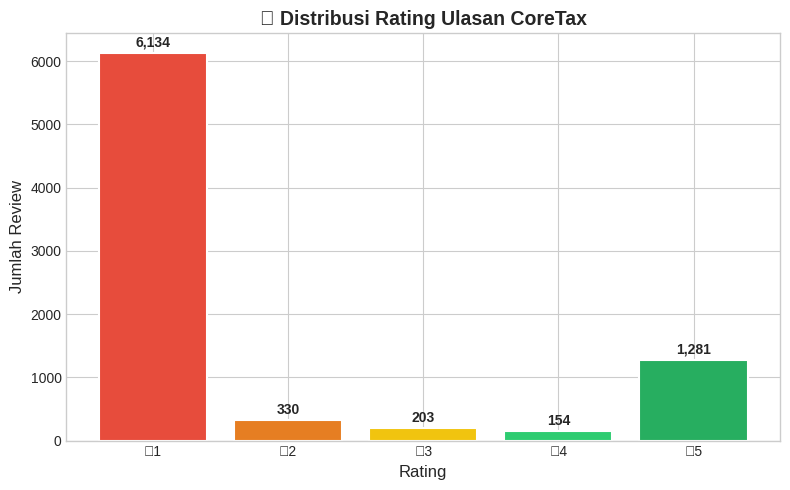

In [10]:
# 1. Distribusi Rating
plot_rating_distribution(df, save_path='../results/figures/eda/rating_distribution.png')

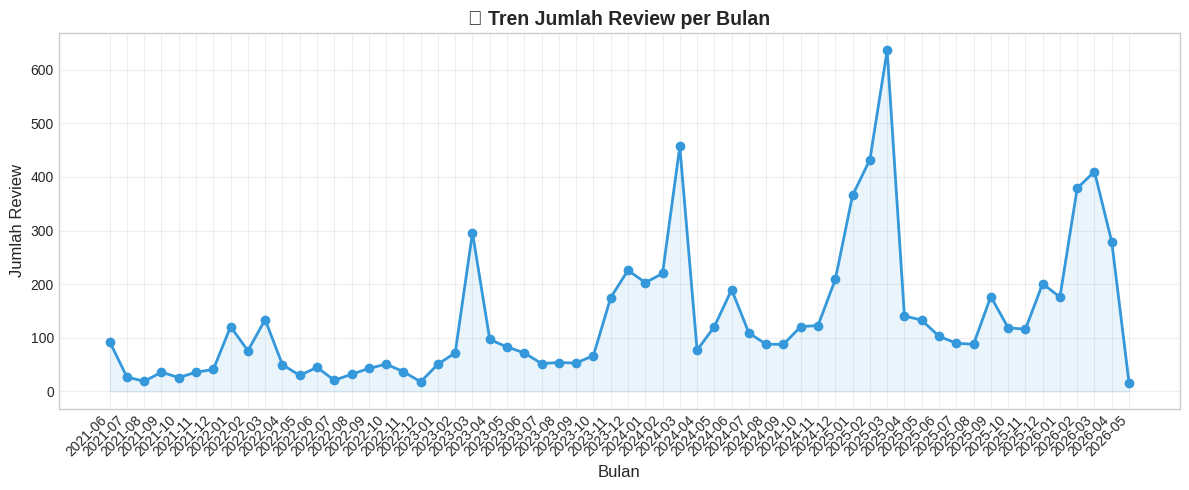

In [11]:
# 2. Tren Bulanan
plot_monthly_trend(df, save_path='../results/figures/eda/monthly_trend.png')

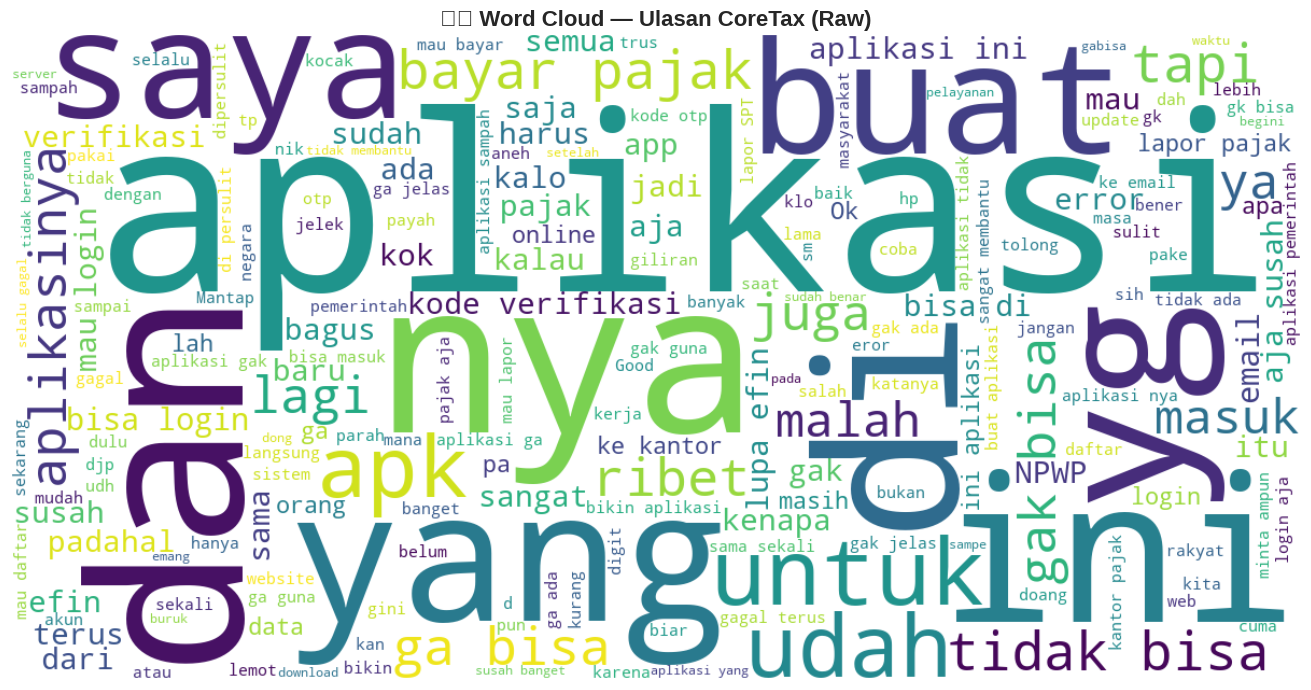

In [12]:
# 3. Word Cloud
plot_wordcloud(
    df['review_text'].tolist(),
    title='☁️ Word Cloud — Ulasan CoreTax (Raw)',
    save_path='../results/figures/eda/wordcloud_raw.png'
)

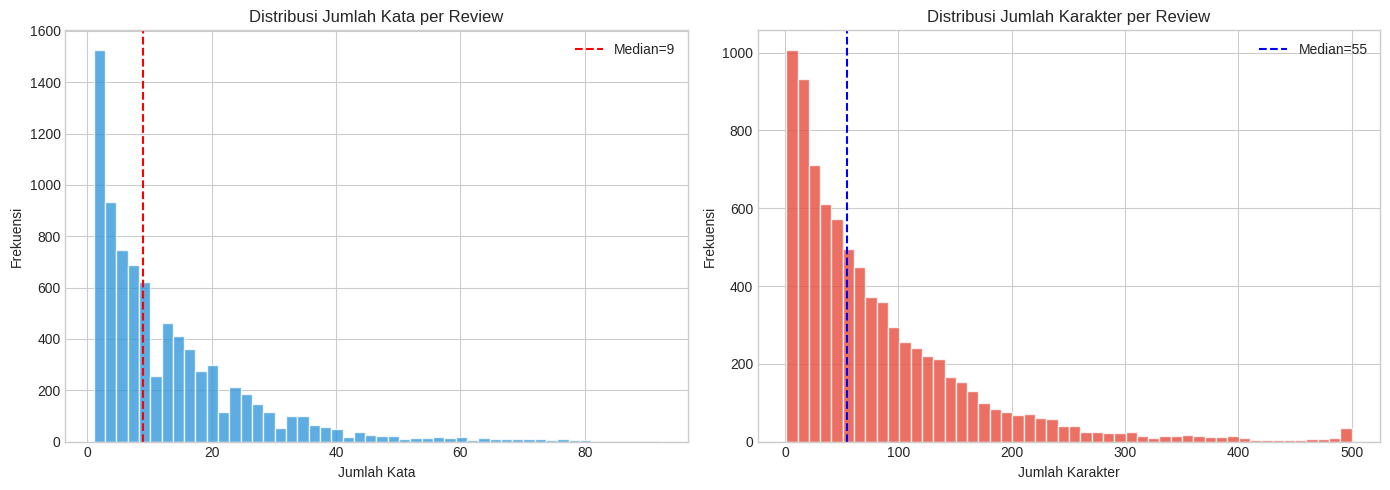

In [13]:
# 4. Distribusi panjang teks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=50, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Jumlah Kata per Review')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f"Median={df['word_count'].median():.0f}")
axes[0].legend()

axes[1].hist(df['char_count'], bins=50, color='#E74C3C', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Jumlah Karakter per Review')
axes[1].axvline(df['char_count'].median(), color='blue', linestyle='--', label=f"Median={df['char_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/eda/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Ringkasan Bagian 0

| Metrik | Nilai |
|--------|-------|
| Total baris (raw) | 8.099 (imbalanced) |
| Missing values | Hanya `app_version` (diisi 'unknown') |
| Kualitas teks | Sangat informal, banyak singkatan & typo |
| Teknik Balancing | Random Undersampling |
| Total baris (balanced) | 609 (203 sampel per kelas) |
| Output | `data/processed/reviews_prepared.csv` (BALANCED) |

## 0.4 — Penyeimbangan Dataset (Undersampling)

In [14]:
# Muat kembali dataset yang sudah dipreprocess
df_preprocessed = pd.read_csv('../data/processed/reviews_prepared.csv')

# Jika kolom 'sentiment' belum ada, buat mapping dari rating
if 'sentiment' not in df_preprocessed.columns:
    # Mapping rating ke sentiment:
    # Rating 1-2 → Negatif
    # Rating 3 → Netral
    # Rating 4-5 → Positif
    def map_rating_to_sentiment(rating):
        if rating <= 2:
            return 'Negatif'
        elif rating == 3:
            return 'Netral'
        else:
            return 'Positif'
    
    df_preprocessed['sentiment'] = df_preprocessed['rating'].apply(map_rating_to_sentiment)
    print("✅ Kolom 'sentiment' berhasil dibuat dari rating")

print("\n📊 Distribusi Sentimen Sebelum Balancing:")
print(df_preprocessed['sentiment'].value_counts())
print(f"\nTotal data: {len(df_preprocessed)}")

# Identifikasi jumlah minimum sampel dari setiap kelas sentimen
min_samples = df_preprocessed['sentiment'].value_counts().min()
print(f"\n🎯 Kelas minority (sampel terkecil): {min_samples}")
print(f"   Akan menyeimbangkan semua kelas ke {min_samples} sampel...")


✅ Kolom 'sentiment' berhasil dibuat dari rating

📊 Distribusi Sentimen Sebelum Balancing:
sentiment
Negatif    6464
Positif    1435
Netral      203
Name: count, dtype: int64

Total data: 8102

🎯 Kelas minority (sampel terkecil): 203
   Akan menyeimbangkan semua kelas ke 203 sampel...


In [15]:
# Terapkan Random Undersampling untuk menyeimbangkan dataset
balanced_df = pd.DataFrame()

for sentiment in df_preprocessed['sentiment'].unique():
    # Filter data untuk setiap sentiment
    subset = df_preprocessed[df_preprocessed['sentiment'] == sentiment]
    
    # Sample secara random dari subset sebanyak min_samples
    resampled = subset.sample(n=min_samples, random_state=42)
    
    # Concat ke balanced_df
    balanced_df = pd.concat([balanced_df, resampled], ignore_index=False)

# Shuffle agar urutan tidak berpola sentimen
df_balanced = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n✅ Distribusi Sentimen Setelah Balancing:")
print(df_balanced['sentiment'].value_counts())
print(f"\nTotal data setelah balancing: {len(df_balanced)}")



✅ Distribusi Sentimen Setelah Balancing:
sentiment
Positif    203
Netral     203
Negatif    203
Name: count, dtype: int64

Total data setelah balancing: 609


In [16]:
# Simpan dataset balanced ke reviews_prepared.csv (overwrite)
output_path = '../data/processed/reviews_prepared.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_balanced.to_csv(output_path, index=False)

print(f"\n✅ Dataset balanced berhasil disimpan ke: {output_path}")
print(f"\n📋 Preview 5 baris pertama dataset balanced:")
print(df_balanced.head())



✅ Dataset balanced berhasil disimpan ke: ../data/processed/reviews_prepared.csv

📋 Preview 5 baris pertama dataset balanced:
         user_name  rating                 date  \
0  Pengguna Google       5  2023-11-20 08:06:30   
1  Pengguna Google       5  2026-03-11 10:59:21   
2  Pengguna Google       3  2021-12-18 16:41:47   
3  Pengguna Google       3  2024-10-07 16:42:59   
4  Pengguna Google       1  2025-11-25 09:23:30   

                                                                                           review_text  \
0                                                                                          𝕊𝕒𝕟𝕪𝕒𝕥 𝕞𝕖𝕟𝕕   
1  terimakasih dengan adanya aplikasi ini memudahkan saya untuk mengisi SPT Tampa harus ke kantor p...   
2  Nunggu kode verifikasi ga msk2 pdh udh dicoba berkali2 tp ga da emai yg msk udh d cek d folder l...   
3                                                                           Mau daftar tapi tidak bisa   
4  sangat amat tidak membantu, mendin

In [17]:
print("\n✅ Bagian 0 selesai!")
print("   📂 Dataset preprocessing & balancing selesai")
print("   💾 Dataset balanced tersimpan di: data/processed/reviews_prepared.csv")
print("   📊 Siap untuk tahap Labeling & Preprocessing selanjutnya")


✅ Bagian 0 selesai!
   📂 Dataset preprocessing & balancing selesai
   💾 Dataset balanced tersimpan di: data/processed/reviews_prepared.csv
   📊 Siap untuk tahap Labeling & Preprocessing selanjutnya
